# Model

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
API_key = os.getenv("GOOGLE_API_KEY")
llm_model = "gemini-2.5-flash"

In [3]:
os.environ["LANGCHAIN_PROJECT"] = " Chatbot Summarizing Messages and Memory"

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [5]:
model = ChatGoogleGenerativeAI(
                    model=llm_model,
                    temperature=0,
                    timeout=None,
                    max_retries=2)

# summary 

In [6]:
from langgraph.graph import MessagesState
class State(MessagesState):
    summary: str

In [7]:
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage

In [8]:
# Define the logic to call the model
def call_model(state: State):
    
    # Get summary if it exists
    summary = state.get("summary", "")

    # If there is summary, then we add it
    if summary:
        
        # Add summary to system message
        system_message = f"Summary of conversation earlier: {summary}"

        # Append summary to any newer messages
        messages = [SystemMessage(content=system_message)] + state["messages"]
    
    else:
        messages = state["messages"]
    
    response = model.invoke(messages)
    return {"messages": response}

In [9]:
def summarize_conversation(state: State):
    
    # First, we get any existing summary
    summary = state.get("summary", "")

    # Create our summarization prompt 
    if summary:
        
        # A summary already exists
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )
        
    else:
        summary_message = "Create a summary of the conversation above:"

    # Add prompt to our history
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)
    
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

- We'll add a conditional edge to determine whether to produce a summary based on the conversation length.

In [10]:
from langgraph.graph import END
from typing_extensions import Literal
# Determine whether to end or summarize the conversation
def should_continue(state: State) -> Literal ["summarize_conversation",END]:
    
    """Return the next node to execute."""
    
    messages = state["messages"]
    
    # If there are more than six messages, then we summarize the conversation
    if len(messages) > 6:
        return "summarize_conversation"
    
    # Otherwise we can just end
    return END

# Adding memory

In [11]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START

In [12]:
# Define a new graph
workflow = StateGraph(State)
workflow.add_node("conversation", call_model)
workflow.add_node(summarize_conversation)

In [13]:
# Set the entrypoint as conversation
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

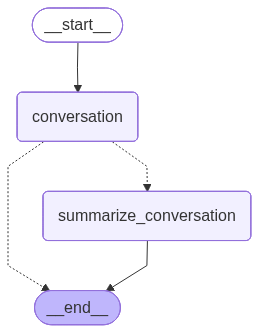

In [14]:
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

# Add Threads

In [15]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}

In [16]:
# Start conversation
input_message = HumanMessage(content="hi! I'm Lance")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Hi Lance! It's great to meet you.

I'm a large language model, trained by Google.

How can I help you today?


In [17]:
input_message = HumanMessage(content="what's my name?")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Your name is Lance! You told me that in your first message. 😊


In [18]:
input_message = HumanMessage(content="i like the 49ers!")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

That's awesome, Lance! The 49ers have a rich history and a really passionate fanbase.

Do you have a favorite player, or a favorite memory of them?


In [19]:
for m in output['messages']:
    m.pretty_print()

================================ Human Message =================================

hi! I'm Lance
================================== Ai Message ==================================

Hi Lance! It's great to meet you.

I'm a large language model, trained by Google.

How can I help you today?
================================ Human Message =================================

what's my name?
================================== Ai Message ==================================

Your name is Lance! You told me that in your first message. 😊
================================ Human Message =================================

i like the 49ers!
================================== Ai Message ==================================

That's awesome, Lance! The 49ers have a rich history and a really passionate fanbase.

Do you have a favorite player, or a favorite memory of them?


# so now should_continue will work 

In [21]:
graph.get_state(config).values.get("summary","")

''

In [22]:
input_message = HumanMessage(content="i like Nick Bosa, isn't he the highest paid defensive player?")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

You're absolutely right, Lance! Nick Bosa signed a massive five-year, \$170 million contract extension with the 49ers in September 2023.

At the time he signed it, it made him the **highest-paid defensive player in NFL history** by a significant margin, with an average annual value of \$34 million. He's an absolute game-wrecker and a huge part of the 49ers' defense!


In [23]:
graph.get_state(config).values.get("summary","")

"Here's a summary of our conversation so far:\n\nThe conversation began with you, Lance, introducing yourself. You then shared that you are a fan of the 49ers and specifically mentioned liking Nick Bosa. We discussed Nick Bosa's contract, confirming that he is indeed the highest-paid defensive player in NFL history due to his \\$170 million extension signed in September 2023."